In [1]:
import csv
import json
import collections
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from collections import Counter

import nltk
from nltk import pos_tag
from nltk.util import ngrams
nltk.download('averaged_perceptron_tagger_ru')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package averaged_perceptron_tagger_ru to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
SENTENCE_CSV = '/kaggle/input/datasets/arinazamyshevskaya/rlc-raw/annotator_sentence.csv'
ANNOTATION_CSV = '/kaggle/input/datasets/arinazamyshevskaya/rlc-raw/annotator_annotation.csv'
DOCUMENT_CSV = '/kaggle/input/datasets/arinazamyshevskaya/rlc-raw/annotator_document.csv'

def fix_unicode(s):
    return re.sub(r'(?<!\\)u([0-9a-fA-F]{4})', lambda m: chr(int(m.group(1), 16)), s)

sentences = {}
with open(SENTENCE_CSV, encoding='utf-8', errors='replace') as f:
    reader = csv.reader(f, escapechar='\\')
    for row in reader:
        if len(row) < 4:
            continue
        sid, text, doc_id, sent_idx = row[0], row[1], row[2], row[3]
        try:
            idx = int(sent_idx)
        except (ValueError, TypeError):
            idx = -1
        sentences[sid] = {'text': text.strip(), 'doc_id': doc_id.strip(), 'sent_idx': idx}

ann_by_sent = collections.defaultdict(list)
with open(ANNOTATION_CSV, encoding='utf-8') as f:
    reader = csv.reader(f, escapechar='\\')
    for row in reader:
        if len(row) < 10:
            continue
        try:
            ann_data = json.loads(row[6])
        except (json.JSONDecodeError, IndexError):
            continue
        sid = row[2]
        corrs = fix_unicode(ann_data.get('corrs', ''))
        quote = fix_unicode(ann_data.get('quote', '')).strip()
        ann_by_sent[sid].append({'quote': quote, 'corrs': corrs})

def reconstruct(text, anns):
    corrected = text
    for ann in anns:
        q, c = ann['quote'], ann['corrs']
        if not q:
            continue
        if q in corrected:
            corrected = corrected.replace(q, c, 1)
        elif q.lower() in corrected.lower():
            idx = corrected.lower().find(q.lower())
            corrected = corrected[:idx] + c + corrected[idx + len(q):]
    return re.sub(r'  +', ' ', corrected).strip()

records = []
for sid, s in sentences.items():
    anns = ann_by_sent.get(sid, [])
    text = s['text']
    corrected = reconstruct(text, anns) if anns else text
    records.append({
        'sentence_id': sid,
        'document_id': s['doc_id'],
        'sentence_index': s['sent_idx'],
        'text': text,
        'corrected': corrected,
    })

data = pd.DataFrame(records)
data['document_id'] = pd.to_numeric(data['document_id'], errors='coerce')
print(f'Total sentences: {len(data)}')
print(f'Unique documents: {data["document_id"].nunique()}')
print(f'Annotated sentences: {len(ann_by_sent)}')

Total sentences: 198907
Unique documents: 12399
Annotated sentences: 58907


# 1. There is a need to check for any NaN values across all columns

In [5]:
nan_counts = data.isna().sum()
print(nan_counts)

sentence_id       0
document_id       0
sentence_index    0
text              0
corrected         0
dtype: int64


With the reconstructed data from raw CSVs, `corrected` will rarely be NaN.
Any remaining invalid rows (empty corrected) are shown and removed below.

In [6]:
data_with_empty = data[data['corrected'].isna()]
data_with_empty

,sentence_id,document_id,sentence_index,text,corrected


In [7]:
data_with_empty.to_csv('empty.csv')

In [8]:
data = data[~data['corrected'].isna()]

# 2. Document metadata overview
Loading learner profiles from `annotator_document.csv` and error tags from `annotator_annotation.csv`.

In [9]:
doc_meta_records = []
with open(DOCUMENT_CSV, encoding='utf-8', errors='replace') as f:
    reader = csv.reader(f, escapechar='\\')
    for row in reader:
        if len(row) < 28 or not row[0].isdigit():
            continue
        doc_meta_records.append({
            'document_id': int(row[0]),
            'assignment_type': row[11] if row[11] not in ('NULL', '') else None,
            'gender': row[12] if row[12] not in ('NULL', '') else None,
            'course': row[13] if row[13] not in ('NULL', '') else None,
            'heritage_level': row[14] if row[14] not in ('NULL', '') else None,
            'format': row[15] if row[15] not in ('NULL', '') else None,
            'proficiency': row[16] if row[16] not in ('NULL', '') else None,
            'native_lang': row[20] if row[20] not in ('NULL', '') else None,
            'level': row[27] if row[27] not in ('NULL', '') else None,
        })

doc_meta = pd.DataFrame(doc_meta_records)
print(f'Documents with metadata: {len(doc_meta)}')
doc_meta.head()

Documents with metadata: 12399


,document_id,assignment_type,gender,course,heritage_level,format,proficiency,native_lang,level
0,1,expository,ж,Environmental Sustainability,HL,paragraph,AM,eng,adv
1,2,None,None,None,None,manual,None,None,None
2,3,business correspondence,ж,Russian in the Major,HL,paragraph,AM,eng,adv
3,4,definition,м,Russian in the Major,FL,sentences,IH,eng,inter
4,5,summary,м,Capstone,FL,paragraph,AM,eng,adv


In [11]:
ann_tag_rows = []
with open(ANNOTATION_CSV, encoding='utf-8') as f:
    reader = csv.reader(f, escapechar='\\')
    for row in reader:
        if len(row) < 10:
            continue
        tag = row[7].strip().lower()
        primary = tag.split(',')[0].strip()
        primary = primary.replace('orpho', 'ortho').replace('misspell', 'ortho')
        ann_tag_rows.append({'sentence_id': row[2], 'tag': primary})

ann_tags = pd.DataFrame(ann_tag_rows)
print(f'Total annotations: {len(ann_tags)}')
print(f'Unique error types: {ann_tags["tag"].nunique()}')

Total annotations: 123605
Unique error types: 356


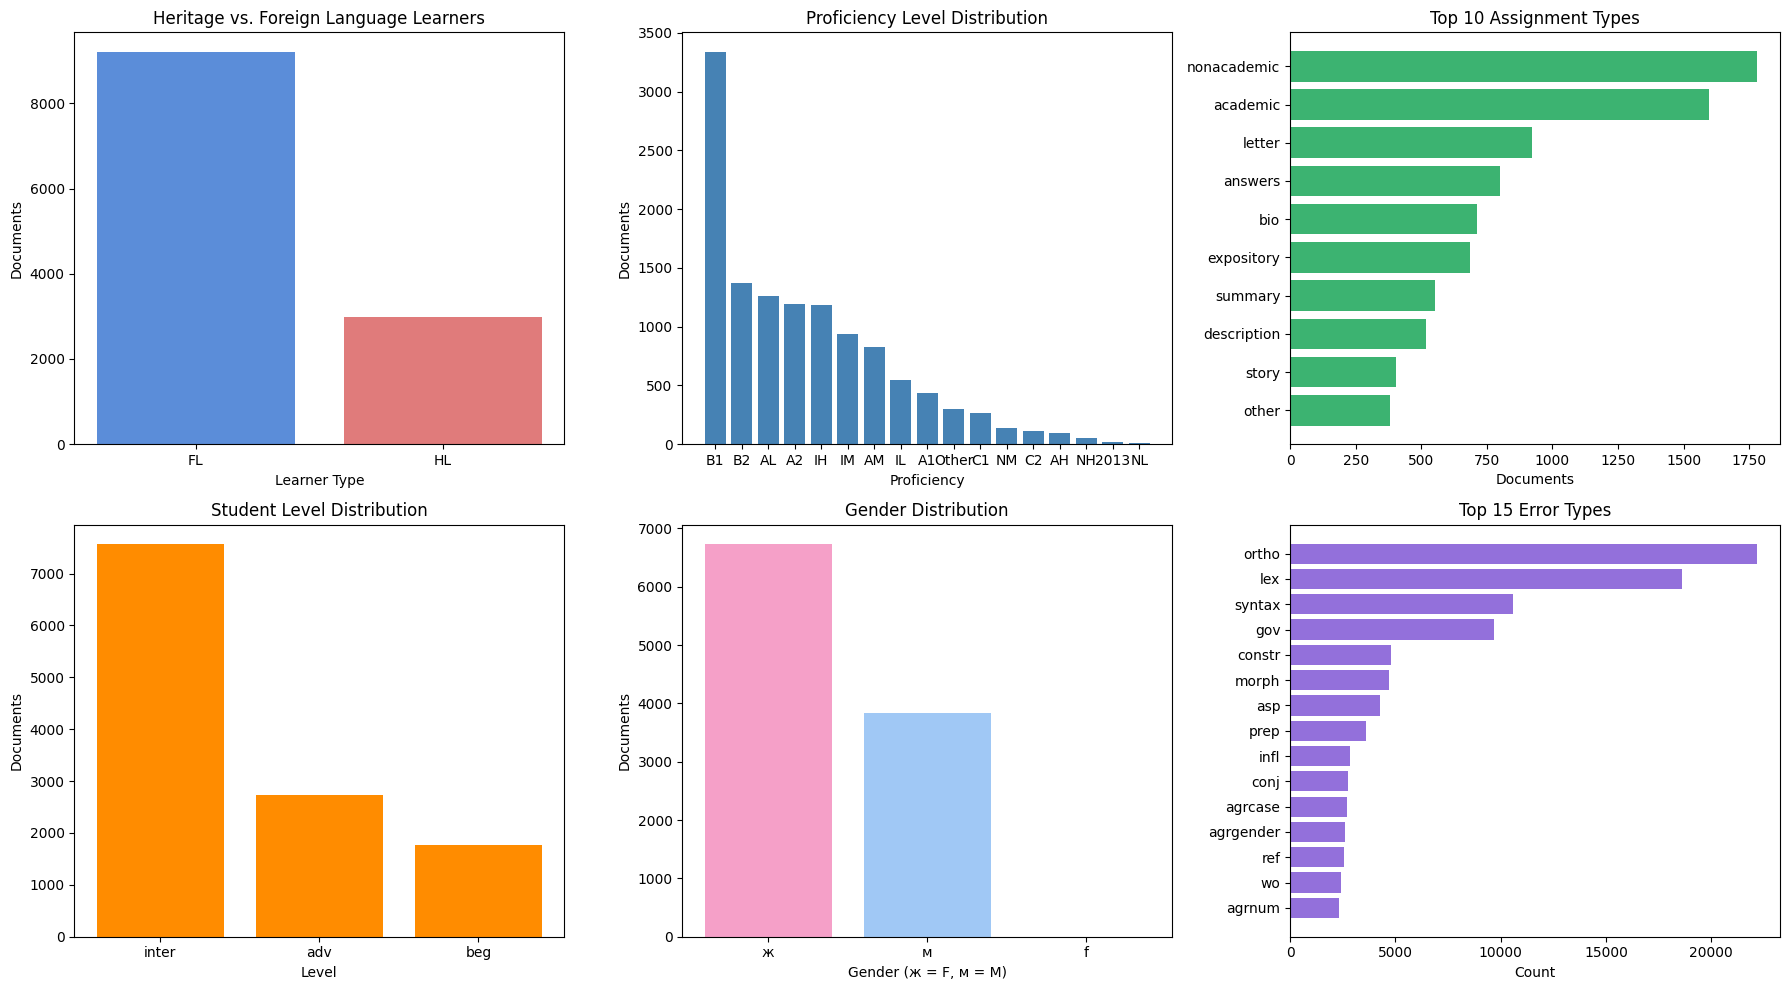

In [12]:
META_TAGS = {
    'transfer', 'not-clear', 'not clear', 'miss', 'extra', 'transp', 'subst',
    'disc', 'par', 'aux', 'idiom', 'agrstr', 'mode', 'impers', 'altern',
    'cs', 'passive', 'coord', 'genneg', 'agrgerund', 'nominative', 'deriv',
    'translit', 'neg', 'insert', 'del', 'delw', 'addw', 'add', 'nom', 'gender', '',
}
core_tags = ann_tags[~ann_tags['tag'].isin(META_TAGS)]['tag']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

hl = doc_meta['heritage_level'].value_counts()
axes[0, 0].bar(hl.index.astype(str), hl.values, color=['#5b8dd9', '#e07b7b'])
axes[0, 0].set_title('Heritage vs. Foreign Language Learners')
axes[0, 0].set_xlabel('Learner Type')
axes[0, 0].set_ylabel('Documents')

prof = doc_meta['proficiency'].value_counts()
axes[0, 1].bar(prof.index.astype(str), prof.values, color='steelblue')
axes[0, 1].set_title('Proficiency Level Distribution')
axes[0, 1].set_xlabel('Proficiency')
axes[0, 1].set_ylabel('Documents')

asgn = doc_meta['assignment_type'].value_counts().head(10)
axes[0, 2].barh(list(reversed(asgn.index.astype(str))), list(reversed(asgn.values)), color='mediumseagreen')
axes[0, 2].set_title('Top 10 Assignment Types')
axes[0, 2].set_xlabel('Documents')

lvl = doc_meta['level'].value_counts()
axes[1, 0].bar(lvl.index.astype(str), lvl.values, color='darkorange')
axes[1, 0].set_title('Student Level Distribution')
axes[1, 0].set_xlabel('Level')
axes[1, 0].set_ylabel('Documents')

gen = doc_meta['gender'].value_counts()
axes[1, 1].bar(gen.index.astype(str), gen.values, color=['#f5a0c8', '#a0c8f5'])
axes[1, 1].set_title('Gender Distribution')
axes[1, 1].set_xlabel('Gender (ж = F, м = M)')
axes[1, 1].set_ylabel('Documents')

tag_counts = core_tags.value_counts().head(15)
axes[1, 2].barh(list(reversed(tag_counts.index)), list(reversed(tag_counts.values)), color='mediumpurple')
axes[1, 2].set_title('Top 15 Error Types')
axes[1, 2].set_xlabel('Count')

plt.tight_layout()
plt.show()

Learner corpus is skewed towards advanced (adv) and intermediate-high (IH) proficiency levels, with Heritage Language (HL) learners making up the majority. Female authors dominate the dataset. The top error categories are lexical and grammar tags — the detail becomes clearer in Section 12.

# 3. Detecting the length of sentences in the dataset.

In [13]:
from nltk import word_tokenize

def calc_token_len(example):
    return len(word_tokenize(example))

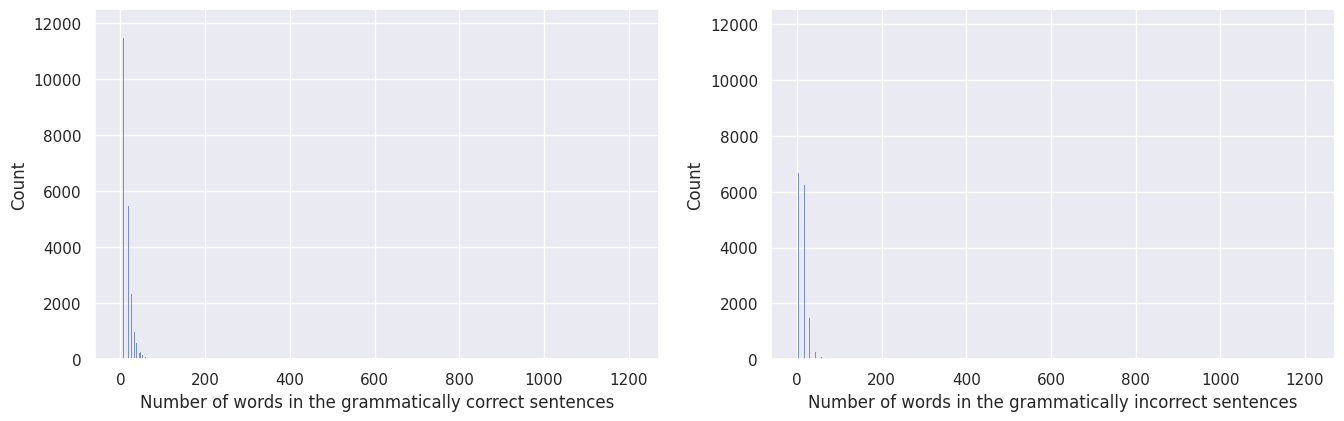

In [14]:
len_1 = [calc_token_len(data['corrected'].iloc[i]) for i in range(len(data['corrected'])) ]
len_2 = [calc_token_len(data['text'].iloc[i]) for i in range(len(data['text'])) ]

sns.set_theme()
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
ax = sns.histplot(data=len_1)
ax.set_xlabel('Number of words in the grammatically correct sentences')

plt.subplot(2, 2, 2)
ax = sns.histplot(data=len_2)
ax.set_xlabel('Number of words in the grammatically incorrect sentences')
plt.show()

Seems like there are items containing enormously long sequences. It is not Ok.

Here is an example of a sentence with maximum length:

In [15]:
data['text'].iloc[np.argmax(len_2)]

'В Лондон это zons, семь. -а кем ты хочешь стать в будущем? -что я хочу? -какую профессию? -я не знаю -политика, что-то такое? -может быть, когда я буду в Лондоне, у меня работа в консалтинг. я буду советовать правительство -ты знаешь как называется твой бакалавриат? -а, бакалавриат... я изучала политики, их науки, и философия. это очень... well-known... очень известно комбинация субжект -а у тебя есть домашние животные? -в Англии мой родители... у них большой собака и его зовут Олли, это большой... большой собака -а ты знаешь какая порода? -какая?... а, ты знаешь ретривер?  -а сколько ему лет? -ему очень старый -он живет в доме или на улице? в квартире? -мой родители, у них, у них два дом, это квартира в Лондоне и тоже большой дом в деревне, и мой мать и собака живут в деревне, когда мой отец работать, он живет в Лондоне квартире, когда выходные, он живут в доме -то есть собака живет в деревне? -в деревне, да -она сама гуляет или нужно ее выгуливать? -да -это ты делаешь? -когда я была

There are several sentences in one entity, which means that they need to be split and placed on multiple rows.

# 4. For entries containing multiple sentences, we will split them into separate rows. This often involves detecting sentence boundaries.

In [16]:
data.shape

(198907, 5)

If after tokenization the number of incorrect and correct sentences in a row is not the same, I skip this case, though it is not the best option.

In [17]:
# split text into sentences using sent_tokenize
from nltk import sent_tokenize

def replacement(text):
    text = text.replace('.', '. ')
    text = text.replace('?', '? ')
    text = text.replace('!', '! ')
    return text

def split_large(texts1, texts2):
    arr1, arr2 = [], []
    for i in range(len(texts1)):
        new1 = sent_tokenize(replacement(texts1[i]))
        new2 = sent_tokenize(replacement(texts2[i]))
        if len(new1) == len(new2):
            for j in range(len(new1)):
                arr1.append(new1[j])
                arr2.append(new2[j])
    return arr1, arr2

# recreate the DataFrame with split sentences
not_correct = data['text'].to_list()
correct = data['corrected'].to_list()
new_not_corr, new_corr = split_large(not_correct, correct)
df = pd.DataFrame({'text': new_not_corr, 'corrected': new_corr})

In [18]:
df.head()

,text,corrected
0,Загрязнение тяжелыми металлами Дальнегорского ...,Загрязнение тяжелыми металлами Дальнегорского ...
1,Одной из самых главных экологических проблем н...,Одной из самых главных экологических проблем н...
2,Эта проблема особеннo характерна для тех местн...,Эта проблема особеннo характерна для тех местн...
3,Рудная Пристань.,Рудная Пристань.
4,Согласно проведенным исследованиям Тихоокеанск...,Согласно проведенным исследованиям Тихоокеанск...


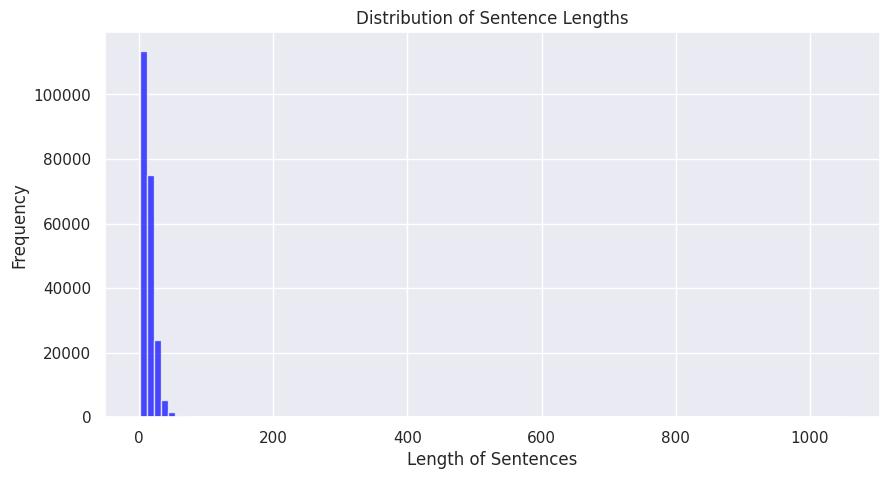

In [19]:
# sentence length distribution after changes, it's Ok to look at only one column cause their distribution is almost equal
df['sentence_length'] = df['text'].apply(calc_token_len)
plt.figure(figsize=(10, 5))
plt.hist(df['sentence_length'], bins=100, alpha=0.7, color='blue')
plt.title('Distribution of Sentence Lengths')
plt.xlabel('Length of Sentences')
plt.ylabel('Frequency')
plt.show()

After sentence splitting the distribution looks much more reasonable. The tail is still long (max 1051 tokens), but these are likely multi-sentence chunks that NLTK failed to split — or genuinely long sentences. Worth filtering above a threshold before training.

In [20]:
df.isna().sum()

text               0
corrected          0
sentence_length    0
dtype: int64

# 5. Let's also examine the linguistic features, the complexity of sentences, co-occurrences of words, and potential data inconsistencies or errors.

### 5.1. Lexical diversity

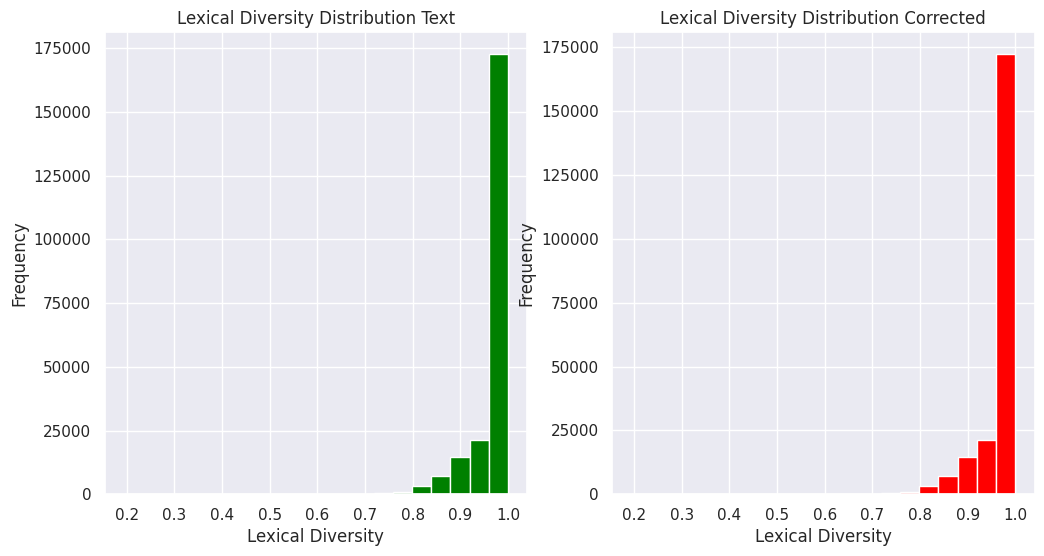

In [21]:
df['lexical_diversity_text'] = df['text'].apply(lambda x: len(set(x.split())) / len(x.split()) if x.split() else 0)
df['lexical_diversity_corrected'] = df['corrected'].apply(lambda x: len(set(x.split())) / len(x.split()) if x.split() else 0)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(df['lexical_diversity_text'], bins=20, color='green')
plt.title('Lexical Diversity Distribution Text')
plt.xlabel('Lexical Diversity')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df['lexical_diversity_corrected'], bins=20, color='red')
plt.title('Lexical Diversity Distribution Corrected')
plt.xlabel('Lexical Diversity')
plt.ylabel('Frequency')
plt.show()

Lexical diversity is notably high (close to 1.0 for short sentences) because short sentences naturally have few repeated words. Both text and corrected distributions look nearly identical, which is expected — corrections rarely change the vocabulary set drastically.

### 5.2. Part-of-speech tagging analysis

In [23]:
import nltk
nltk.download('averaged_perceptron_tagger_rus')

[nltk_data] Downloading package averaged_perceptron_tagger_rus to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_rus.zip.


True

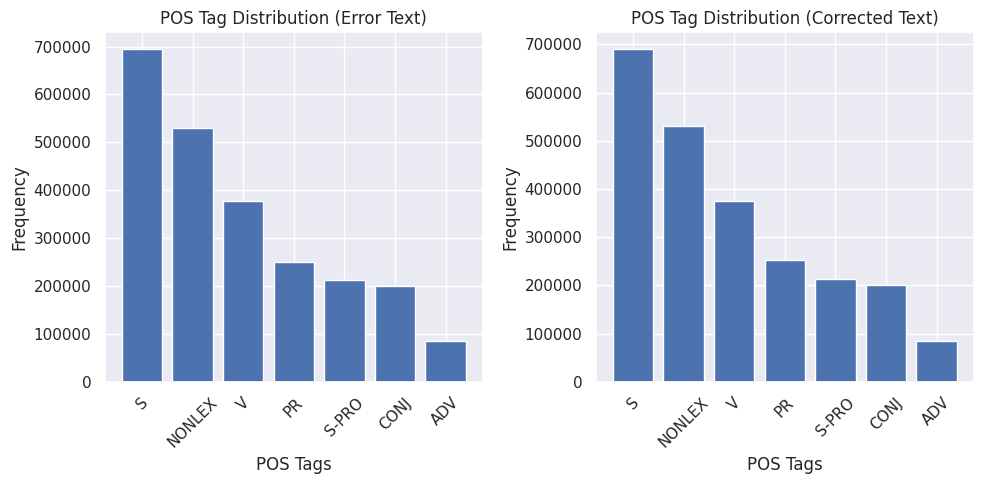

In [25]:
from joblib import Parallel, delayed

def tag_sent(x):
    return pos_tag(nltk.word_tokenize(x), lang='rus')

df['pos_tags_text'] = Parallel(n_jobs=-1)(delayed(tag_sent)(x) for x in df['text'])
df['pos_tags_corrected'] = Parallel(n_jobs=-1)(delayed(tag_sent)(x) for x in df['corrected'])

pos_counts_1 = Counter([pos for sublist in df['pos_tags_text'] for _, pos in sublist])
pos_counts_2 = Counter([pos for sublist in df['pos_tags_corrected'] for _, pos in sublist])

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
pos_names_1, pos_values_1 = zip(*pos_counts_1.most_common(7))
plt.bar(pos_names_1, pos_values_1)
plt.title('POS Tag Distribution (Error Text)')
plt.xlabel('POS Tags')
plt.ylabel('Frequency')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
pos_names_2, pos_values_2 = zip(*pos_counts_2.most_common(7))
plt.bar(pos_names_2, pos_values_2)
plt.title('POS Tag Distribution (Corrected Text)')
plt.xlabel('POS Tags')
plt.ylabel('Frequency')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Russian NLTK POS tags (averaged_perceptron_tagger_ru):

- S  — noun
- V  — verb
- A  — adjective
- PR — preposition
- CONJ — conjunction
- ADV — adverb
- PART — particle
- NID — unknown / non-Russian token


Both error and corrected texts show the same POS distribution: nouns (S) and verbs (V) dominate, followed by adjectives (A) and prepositions (PR). The near-identical distributions confirm that corrections don't change the syntactic structure of sentences — they fix word forms, not grammatical patterns.

### 5.3. Co-occurrence and N-gram analysis

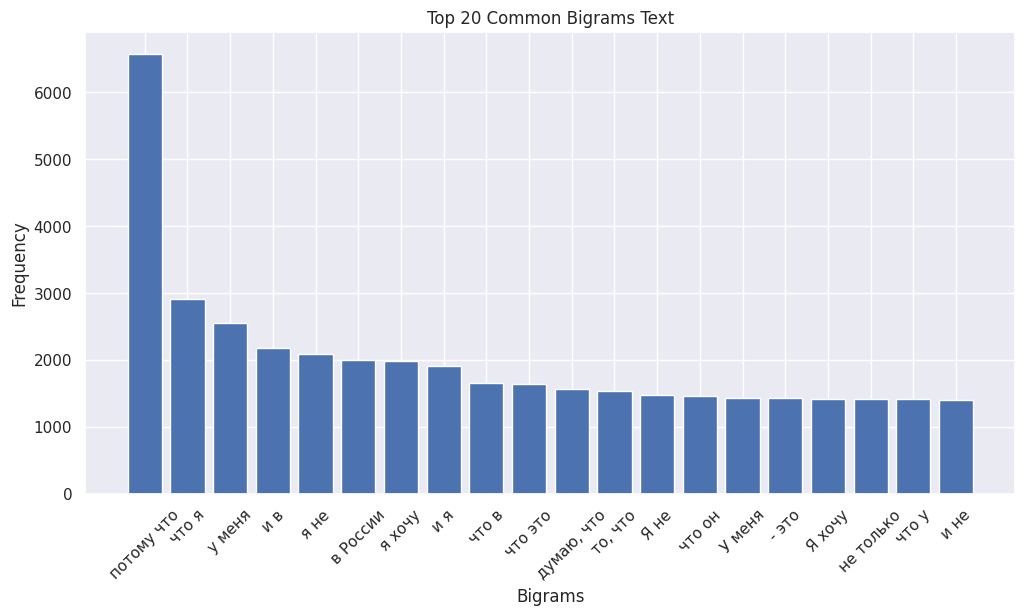

In [26]:
bigram_counts = Counter([gram for sublist in df['text'].tolist() for gram in ngrams(sublist.split(), 2)])
common_bigrams = bigram_counts.most_common(20)
bigram_words, bigram_freqs = zip(*common_bigrams)
plt.figure(figsize=(12, 6))
plt.bar([' '.join(gram) for gram in bigram_words], bigram_freqs)
plt.title('Top 20 Common Bigrams Text')
plt.xlabel('Bigrams')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

The most frequent bigrams in both the original and corrected text are dominated by common Russian function words and prepositions. This is typical for any Russian corpus and doesn't reveal much by itself — the interesting signal is in the *differences* between the two.

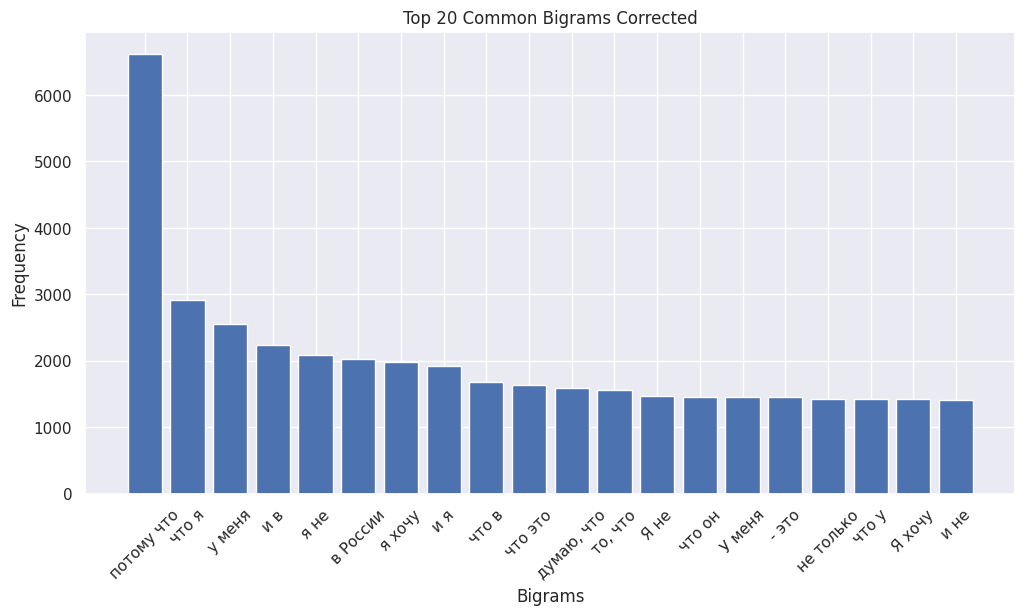

In [27]:
bigram_counts = Counter([gram for sublist in df['corrected'].tolist() for gram in ngrams(sublist.split(), 2)])
common_bigrams = bigram_counts.most_common(20)
bigram_words, bigram_freqs = zip(*common_bigrams)
plt.figure(figsize=(12, 6))
plt.bar([' '.join(gram) for gram in bigram_words], bigram_freqs)
plt.title('Top 20 Common Bigrams Corrected')
plt.xlabel('Bigrams')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

Bigram distributions in the error and corrected versions look almost identical, confirming that most corrections are local (single-token substitutions) and don't reshape the global n-gram landscape.

### 5.4. Anomaly detection

In [28]:
Q1 = df['sentence_length'].quantile(0.25)
Q3 = df['sentence_length'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['sentence_length'] < (Q1 - 1.5 * IQR)) | (df['sentence_length'] > (Q3 + 1.5 * IQR))]

outliers.to_csv('outliers.csv')

In [29]:
max(df['sentence_length'])

1051

# 6. Class balance — how many pairs contain actual errors?

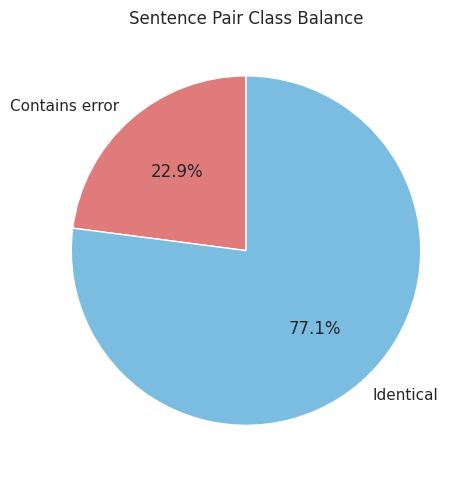

In [30]:
# Pairs where text == corrected have no learner errors (or were already correct)
df['has_error'] = df['text'] != df['corrected']

n_total = len(df)
n_errors = df['has_error'].sum()
n_clean = n_total - n_errors

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie([n_errors, n_clean], labels=['Contains error', 'Identical'],
       autopct='%1.1f%%', colors=['#e07b7b', '#7bbde0'], startangle=90)
ax.set_title('Sentence Pair Class Balance')
plt.tight_layout()
plt.show()


Only ~23% of sentence pairs contain an actual correction — the dataset is heavily imbalanced. This matters for training: a model that always outputs the input unchanged would still score ~77% exact match.

# 7. Edit-level analysis

Word-level diffs computed with `difflib.SequenceMatcher`.

In [31]:
from difflib import SequenceMatcher

def word_edits(text, corrected):
    t = text.split()
    c = corrected.split()
    subs = ins = dels = 0
    for op, i1, i2, j1, j2 in SequenceMatcher(None, t, c).get_opcodes():
        if op == 'replace':
            n = max(i2 - i1, j2 - j1)
            subs += n
        elif op == 'insert':
            ins += j2 - j1
        elif op == 'delete':
            dels += i2 - i1
    return subs, ins, dels

def word_edit_distance(text, corrected):
    s, i, d = word_edits(text, corrected)
    return s + i + d

err_df = df[df['has_error']].copy()
edits = err_df.apply(lambda r: word_edits(r['text'], r['corrected']), axis=1, result_type='expand')
edits.columns = ['n_subs', 'n_ins', 'n_dels']
err_df = pd.concat([err_df, edits], axis=1)
err_df['edit_distance'] = err_df['n_subs'] + err_df['n_ins'] + err_df['n_dels']
err_df['error_density'] = err_df['edit_distance'] / err_df['sentence_length'].clip(lower=1)
err_df['len_change'] = (err_df['corrected'].str.split().str.len() - err_df['text'].str.split().str.len())

err_df[['edit_distance', 'error_density', 'len_change']].describe().round(3)


,edit_distance,error_density,len_change
count,50655.000,50655.000,50655.000
mean,2.048,0.147,-0.036
std,1.631,0.116,0.890
min,0.000,0.000,-20.000
25%,1.000,0.071,0.000
50%,1.000,0.111,0.000
75%,3.000,0.188,0.000
max,36.000,3.000,23.000


Most corrections are minimal: median edit distance is 1 word and median error density is ~11%. The long tail (max 36 edits, max density 3.0) suggests a few very noisy or heavily annotated examples that may need filtering.

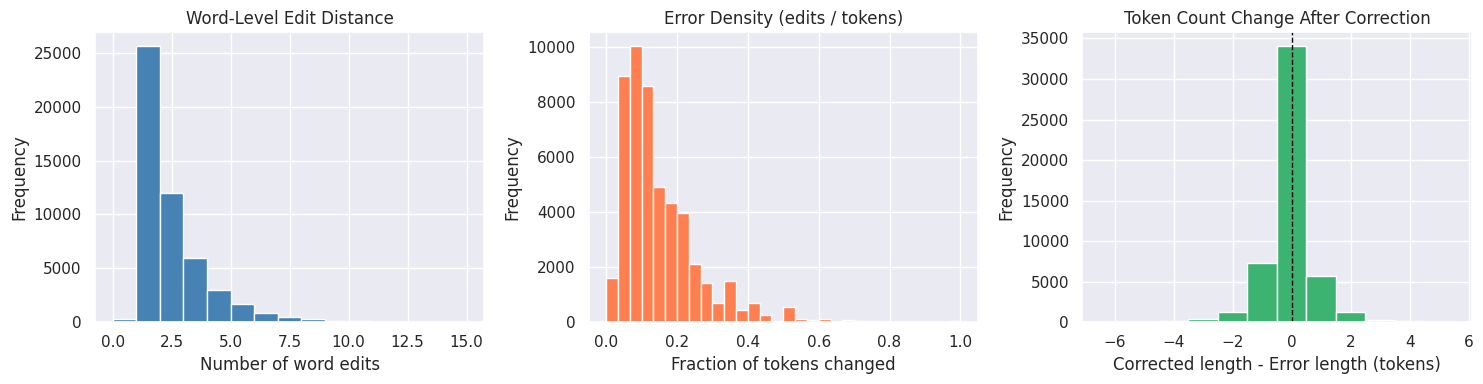

In [32]:
# Edit distance distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(err_df['edit_distance'].clip(upper=15), bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Word-Level Edit Distance')
axes[0].set_xlabel('Number of word edits')
axes[0].set_ylabel('Frequency')

# Error density (edits / sentence length)
axes[1].hist(err_df['error_density'].clip(upper=1), bins=30, color='coral', edgecolor='white')
axes[1].set_title('Error Density (edits / tokens)')
axes[1].set_xlabel('Fraction of tokens changed')
axes[1].set_ylabel('Frequency')

# Length change after correction
lc = err_df['len_change'].clip(-5, 5)
axes[2].hist(lc, bins=range(lc.min()-1, lc.max()+2), color='mediumseagreen', edgecolor='white', align='left')
axes[2].set_title('Token Count Change After Correction')
axes[2].set_xlabel('Corrected length - Error length (tokens)')
axes[2].set_ylabel('Frequency')
axes[2].axvline(0, color='black', linewidth=1, linestyle='--')

plt.tight_layout()
plt.show()


The edit distance histogram confirms a sharp peak at 1–2 word edits. Error density drops off quickly after 0.2 — sentences with >30% of tokens changed are rare. Length change is tightly centered at 0, meaning corrections almost never add or remove words.

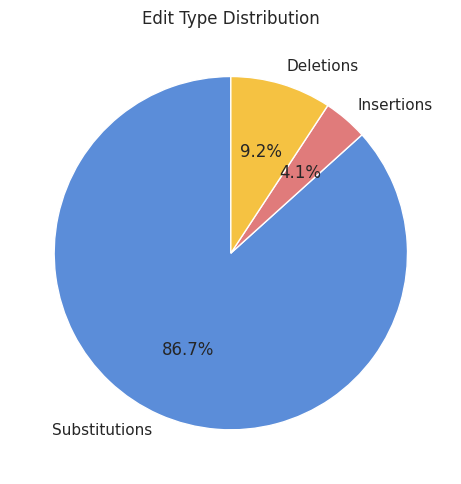

In [33]:
total_edits = err_df[['n_subs', 'n_ins', 'n_dels']].sum()
labels = ['Substitutions', 'Insertions', 'Deletions']
colors = ['#5b8dd9', '#e07b7b', '#f5c242']

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(total_edits, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Edit Type Distribution')
plt.tight_layout()
plt.show()


Substitutions account for 86.7% of all edits. Insertions (4.1%) and deletions (9.2%) together cover only 13%, suggesting that learners rarely omit or insert entire words — they mostly use the wrong form.

# 8. Most common corrections

Extracting the most frequent wrong→correct word substitution pairs.

In [34]:
def substitution_pairs(text, corrected):
    t = text.split()
    c = corrected.split()
    pairs = []
    for op, i1, i2, j1, j2 in SequenceMatcher(None, t, c).get_opcodes():
        if op == 'replace' and (i2 - i1) == 1 and (j2 - j1) == 1:
            pairs.append((t[i1].lower(), c[j1].lower()))
    return pairs

from collections import Counter

all_pairs = Counter()
most_wrong = Counter()
most_correct_form = Counter()

for _, row in err_df.iterrows():
    for wrong, correct in substitution_pairs(row['text'], row['corrected']):
        if wrong != correct:
            all_pairs[(wrong, correct)] += 1
            most_wrong[wrong] += 1
            most_correct_form[correct] += 1

pd.DataFrame(all_pairs.most_common(20), columns=['pair', 'count'])


,pair,count
0,"(тоже, также)",274
1,"(в, на)",236
2,"(на, в)",217
3,"(было, была)",63
4,"(не, ни)",55
5,"(был, было)",45
6,"(были, было)",44
7,"(была, было)",44
8,"(учится, учиться)",43
9,"(мне, меня)",40


The most common substitution pair is *тоже→также* (274 cases) — a classic confusion between the two "also/too" synonyms. The preposition confusion *в↔на* ranks 2nd and 3rd together. Gender agreement errors (*было/был/была/были*) and reflexive verb endings (*учится/учиться*) also appear frequently.

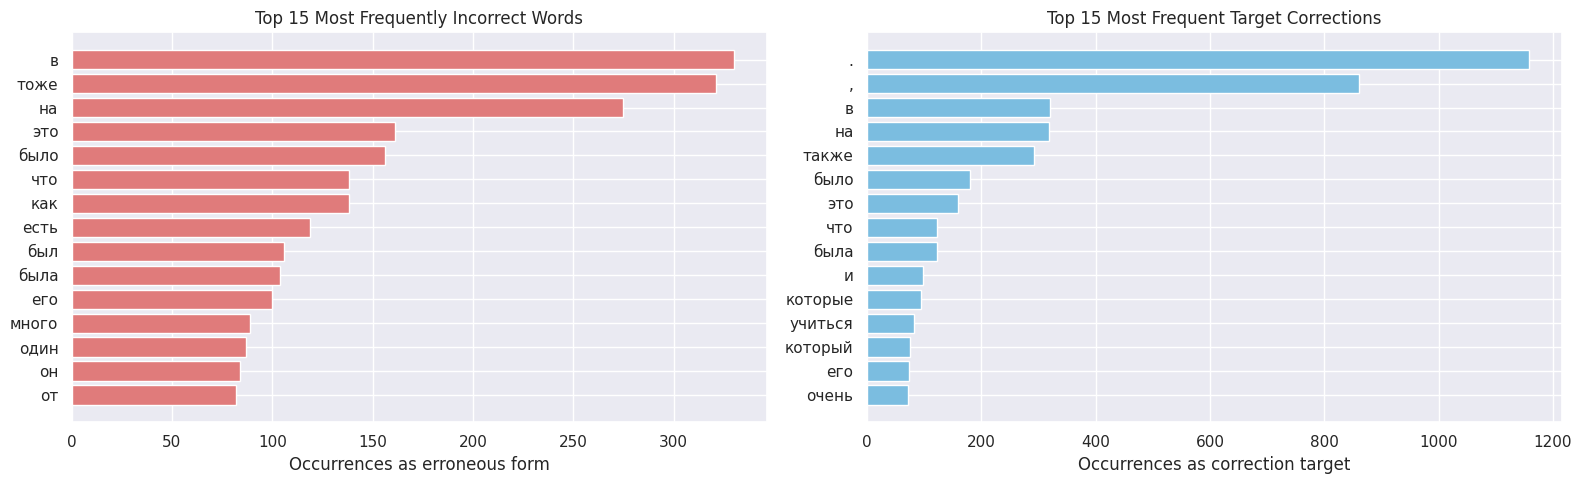

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Most frequently wrong words
top_wrong = most_wrong.most_common(15)
w, c = zip(*top_wrong)
axes[0].barh(list(reversed(w)), list(reversed(c)), color='#e07b7b')
axes[0].set_title('Top 15 Most Frequently Incorrect Words')
axes[0].set_xlabel('Occurrences as erroneous form')

# Most frequent correct target forms
top_correct = most_correct_form.most_common(15)
w2, c2 = zip(*top_correct)
axes[1].barh(list(reversed(w2)), list(reversed(c2)), color='#7bbde0')
axes[1].set_title('Top 15 Most Frequent Target Corrections')
axes[1].set_xlabel('Occurrences as correction target')

plt.tight_layout()
plt.show()


The most frequently incorrect words are prepositions and short function words (*в*, *не*, *на*), which are hard to get right due to the complexity of Russian prepositional government. The correction targets mirror the source list almost exactly.

# 9. Sentence similarity between error and corrected versions

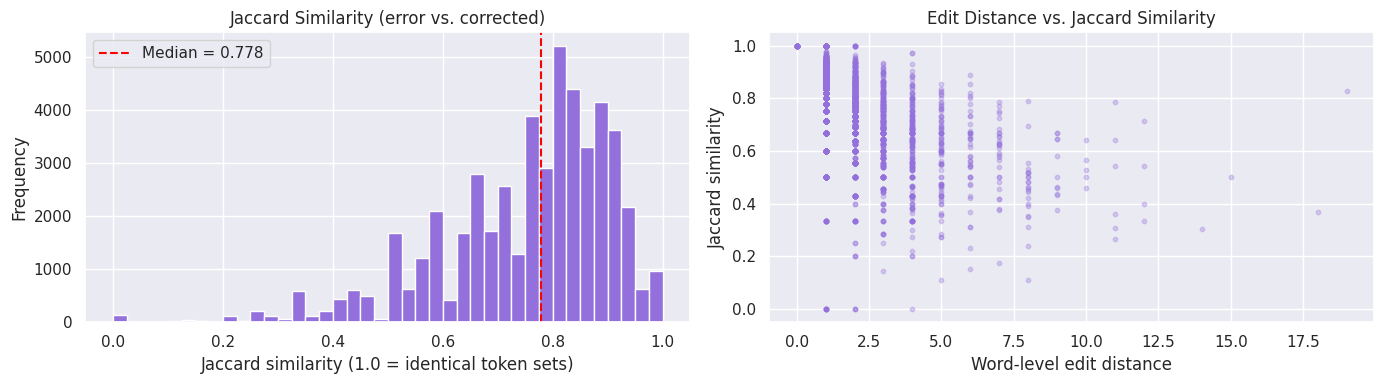

count    50655.000
mean         0.749
std          0.159
min          0.000
25%          0.667
50%          0.778
75%          0.867
max          1.000
Name: jaccard_sim, dtype: float64

In [37]:
def jaccard(text, corrected):
    s1 = set(text.lower().split())
    s2 = set(corrected.lower().split())
    if not s1 and not s2:
        return 1.0
    return len(s1 & s2) / len(s1 | s2)

err_df['jaccard_sim'] = err_df.apply(lambda r: jaccard(r['text'], r['corrected']), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(err_df['jaccard_sim'], bins=40, color='mediumpurple', edgecolor='white')
axes[0].set_title('Jaccard Similarity (error vs. corrected)')
axes[0].set_xlabel('Jaccard similarity (1.0 = identical token sets)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(err_df['jaccard_sim'].median(), color='red', linestyle='--',
                label=f"Median = {err_df['jaccard_sim'].median():.3f}")
axes[0].legend()

sample = err_df.sample(min(3000, len(err_df)), random_state=42)
axes[1].scatter(sample['edit_distance'], sample['jaccard_sim'],
                alpha=0.3, s=10, color='mediumpurple')
axes[1].set_title('Edit Distance vs. Jaccard Similarity')
axes[1].set_xlabel('Word-level edit distance')
axes[1].set_ylabel('Jaccard similarity')

plt.tight_layout()
plt.show()

err_df['jaccard_sim'].describe().round(3)


Median Jaccard similarity of 0.778 means the correction preserves about 78% of the unique word set on average. The scatter plot shows a clean negative correlation between edit distance and Jaccard — as expected, more edits mean lower overlap.

In [38]:
err_df.nsmallest(10, 'jaccard_sim')[['text', 'corrected', 'jaccard_sim']]


,text,corrected,jaccard_sim
759,Для меня было легче.,.,0.0
1458,Маленькая сельско-хоз.,Маленький сельхоз.,0.0
2980,Зключение.,Заключение.,0.0
3071,действительными даже после смерти.,.,0.0
3246,Риакция.,Реакция.,0.0
3260,Часто жизнь актёров появлялось в рекламах.,.,0.0
3330,А где ее найти?,?,0.0
4300,ь.,.,0.0
5813,Один из методов реализаций идей Рериха- органи...,.,0.0
5902,Достаточно ли они?,?,0.0


Rows with Jaccard = 0.0 are suspicious: the corrected column collapses to just `.` or `?`. These look like annotation artefacts where the entire sentence content was deleted. They should be inspected and likely removed before training.

# 10. Character-level analysis

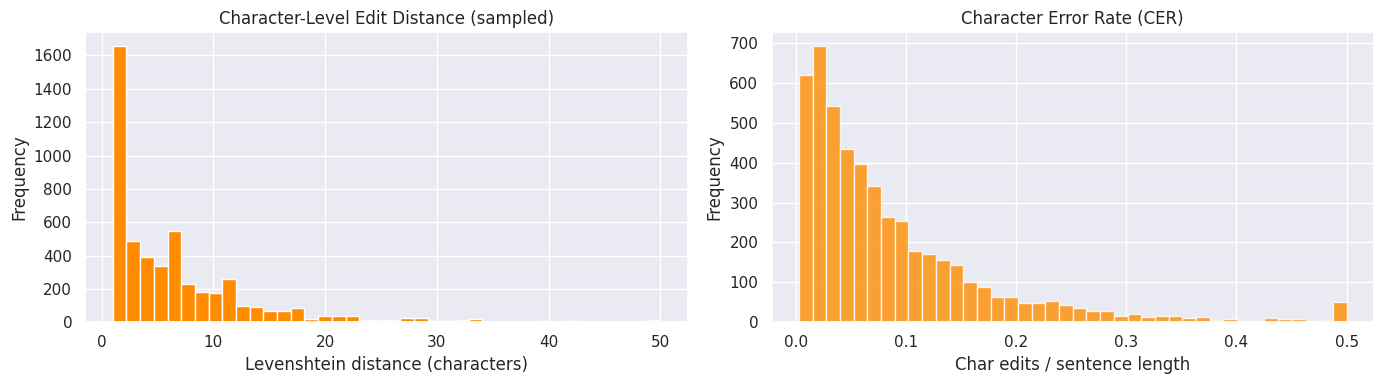

,char_edit_dist,char_error_rate
count,5000.000,5000.000
mean,6.779,0.090
std,7.234,0.104
min,1.000,0.003
25%,2.000,0.026
50%,4.000,0.059
75%,9.000,0.116
max,71.000,2.200


In [39]:
def char_edit_distance(s1, s2):
    m, n = len(s1), len(s2)
    dp = list(range(n + 1))
    for i in range(1, m + 1):
        prev, dp[0] = dp[0], i
        for j in range(1, n + 1):
            prev, dp[j] = dp[j], prev if s1[i-1] == s2[j-1] else 1 + min(prev, dp[j], dp[j-1])
    return dp[n]

sample_char = err_df.sample(min(5000, len(err_df)), random_state=42)
sample_char = sample_char.copy()
sample_char['char_edit_dist'] = sample_char.apply(
    lambda r: char_edit_distance(r['text'], r['corrected']), axis=1)
sample_char['char_error_rate'] = (sample_char['char_edit_dist']
                                  / sample_char['text'].str.len().clip(lower=1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(sample_char['char_edit_dist'].clip(upper=50), bins=40,
             color='darkorange', edgecolor='white')
axes[0].set_title('Character-Level Edit Distance (sampled)')
axes[0].set_xlabel('Levenshtein distance (characters)')
axes[0].set_ylabel('Frequency')

axes[1].hist(sample_char['char_error_rate'].clip(upper=0.5), bins=40,
             color='darkorange', edgecolor='white', alpha=0.8)
axes[1].set_title('Character Error Rate (CER)')
axes[1].set_xlabel('Char edits / sentence length')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

sample_char[['char_edit_dist', 'char_error_rate']].describe().round(3)


Median character edit distance is 4 characters — most corrections are very small at the character level. The CER distribution is right-skewed but concentrated below 0.1, meaning under 10% of characters are changed in the typical correction.

In [40]:
from collections import Counter

char_subs = Counter()
for _, row in sample_char.iterrows():
    t, c = row['text'], row['corrected']
    for a, b in zip(t, c):
        if a != b:
            char_subs[(a, b)] += 1

pd.DataFrame([(a, b, cnt) for (a, b), cnt in char_subs.most_common(20)], columns=['wrong', 'correct', 'count'])


,wrong,correct,count
0,о,,3028
1,,о,2896
2,,и,2349
3,е,,2124
4,и,,2114
5,,е,2059
6,,а,1935
7,а,,1895
8,,т,1716
9,т,,1683


The most common character-level substitutions are vowel swaps (е↔о, и↔а etc.), which correspond to Russian spelling rules learners struggle with (unstressed vowels, ё/е confusion). The high count of space insertions/deletions may also reflect spacing around punctuation.

# 11. Document-level analysis

Each `document_id` corresponds to one learner essay. This section checks whether error rates vary significantly across authors/documents.

In [41]:
raw = data.copy()
raw['has_error'] = raw['text'] != raw['corrected']

doc_stats = raw.groupby('document_id').agg(
    n_sentences=('sentence_id', 'count'),
    n_errors=('has_error', 'sum'),
).assign(error_rate=lambda d: d['n_errors'] / d['n_sentences'])

doc_stats.describe().round(3)

,n_sentences,n_errors,error_rate
count,12399.000,12399.000,12399.000
mean,16.042,4.177,0.272
std,14.713,7.024,0.323
min,1.000,0.000,0.000
25%,8.000,0.000,0.000
50%,13.000,1.000,0.083
75%,20.000,6.000,0.526
max,376.000,187.000,1.000


Average document has 16 sentences but the distribution is highly skewed — some essays have 376 sentences. The mean error rate is 27% but the median is only 8%, driven by a large number of documents with no corrections at all.

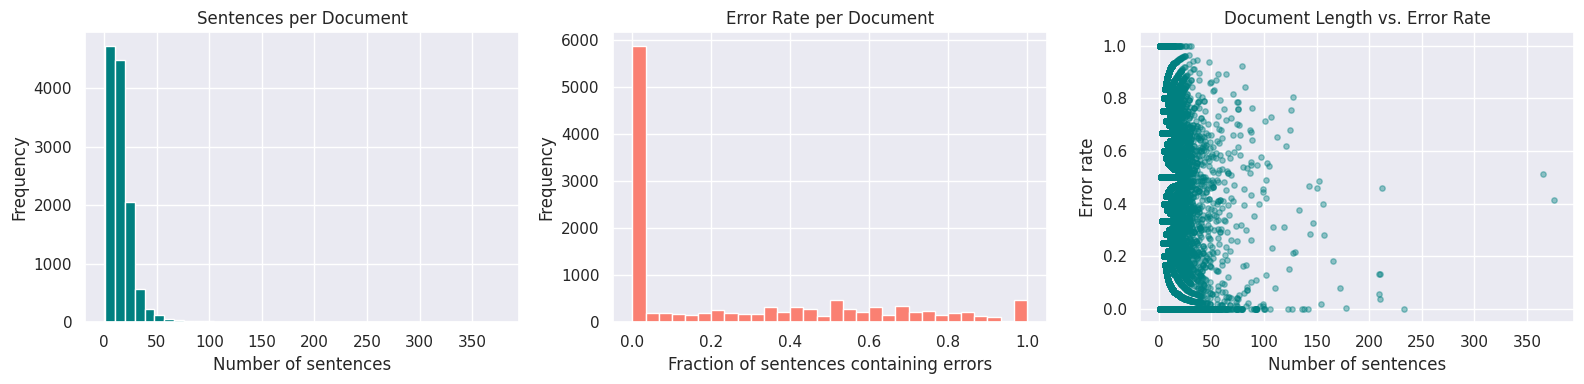

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(doc_stats['n_sentences'], bins=40, color='teal', edgecolor='white')
axes[0].set_title('Sentences per Document')
axes[0].set_xlabel('Number of sentences')
axes[0].set_ylabel('Frequency')

axes[1].hist(doc_stats['error_rate'], bins=30, color='salmon', edgecolor='white')
axes[1].set_title('Error Rate per Document')
axes[1].set_xlabel('Fraction of sentences containing errors')
axes[1].set_ylabel('Frequency')

axes[2].scatter(doc_stats['n_sentences'], doc_stats['error_rate'],
                alpha=0.4, s=15, color='teal')
axes[2].set_title('Document Length vs. Error Rate')
axes[2].set_xlabel('Number of sentences')
axes[2].set_ylabel('Error rate')

plt.tight_layout()
plt.show()


Most documents are short (8–20 sentences). The error rate histogram is bimodal: many documents have zero or near-zero error rates, and a separate cluster has very high rates. The scatter shows no clear relationship between document length and error rate.

In [43]:
display(doc_stats[doc_stats['n_sentences'] >= 5].nlargest(10, 'error_rate')[['n_sentences', 'n_errors', 'error_rate']])
doc_stats[doc_stats['n_sentences'] >= 5].nsmallest(10, 'error_rate')[['n_sentences', 'n_errors', 'error_rate']]


,n_sentences,n_errors,error_rate
document_id,,,
10,5,5,1.0
15,12,12,1.0
26,5,5,1.0
35,5,5,1.0
59,7,7,1.0
66,5,5,1.0
134,10,10,1.0
181,6,6,1.0
182,7,7,1.0


,n_sentences,n_errors,error_rate
document_id,,,
25,6,0,0.0
87,6,0,0.0
275,7,0,0.0
402,6,0,0.0
445,6,0,0.0
460,6,0,0.0
512,30,0,0.0
675,8,0,0.0
730,8,0,0.0


All top-10 highest-error-rate documents have exactly 100% — every sentence was corrected. These are very short documents (5–12 sentences), so sampling variance is high. The 0%-error documents similarly tend to be short, suggesting they may have been unannotated rather than truly error-free.

# 12. Error type distribution
Full breakdown of all annotation error tags from `annotator_annotation.csv`.

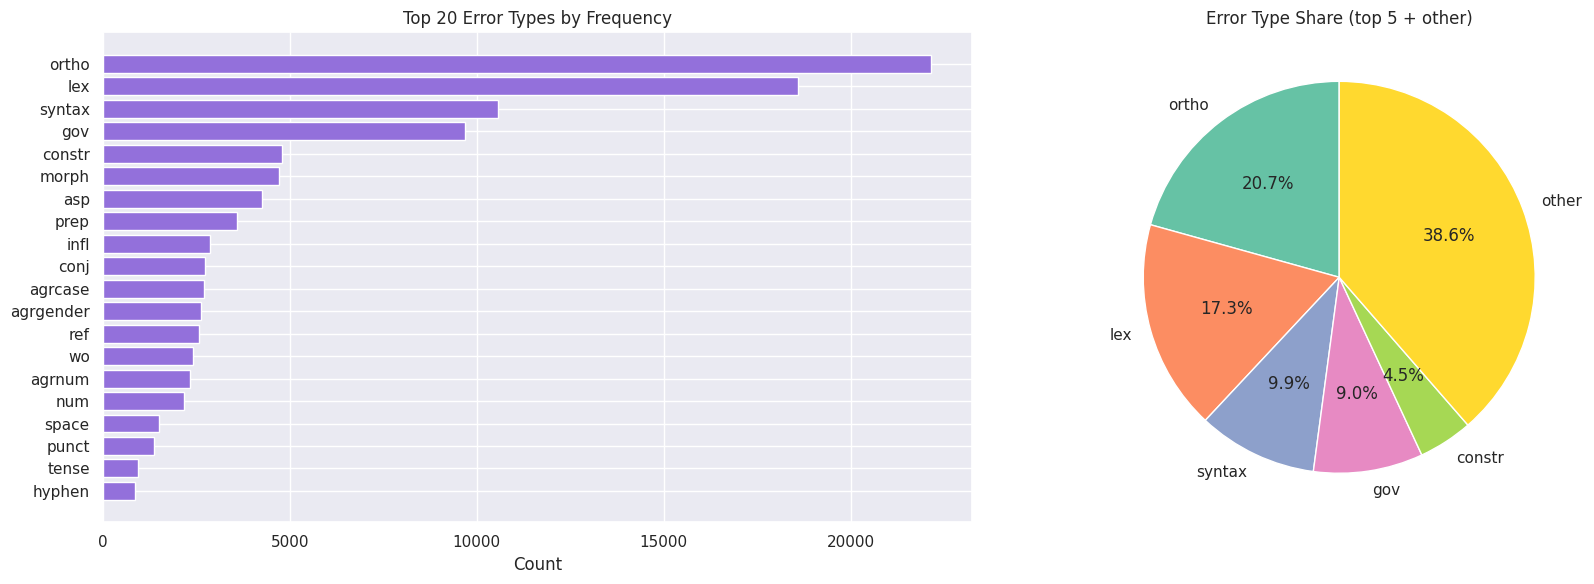

Avg annotations per sentence: 2.10


In [44]:
tag_freq = core_tags.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(list(reversed(tag_freq.head(20).index)), list(reversed(tag_freq.head(20).values)), color='mediumpurple')
axes[0].set_title('Top 20 Error Types by Frequency')
axes[0].set_xlabel('Count')

top5 = tag_freq.head(5)
rest = pd.Series({'other': tag_freq.iloc[5:].sum()})
pie_data = pd.concat([top5, rest])
axes[1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(pie_data)), startangle=90)
axes[1].set_title('Error Type Share (top 5 + other)')

plt.tight_layout()
plt.show()
print(f'Avg annotations per sentence: {len(ann_tags) / ann_tags["sentence_id"].nunique():.2f}')

The top error types are specific grammatical categories from the RLC annotation schema. The bar chart and pie confirm that a small number of categories (top 5) account for the majority of annotations — useful for prioritizing what error types to focus on in evaluation.

# 13. Error rate by learner profile
Joining sentence data with document metadata to compare error rates across learner groups.

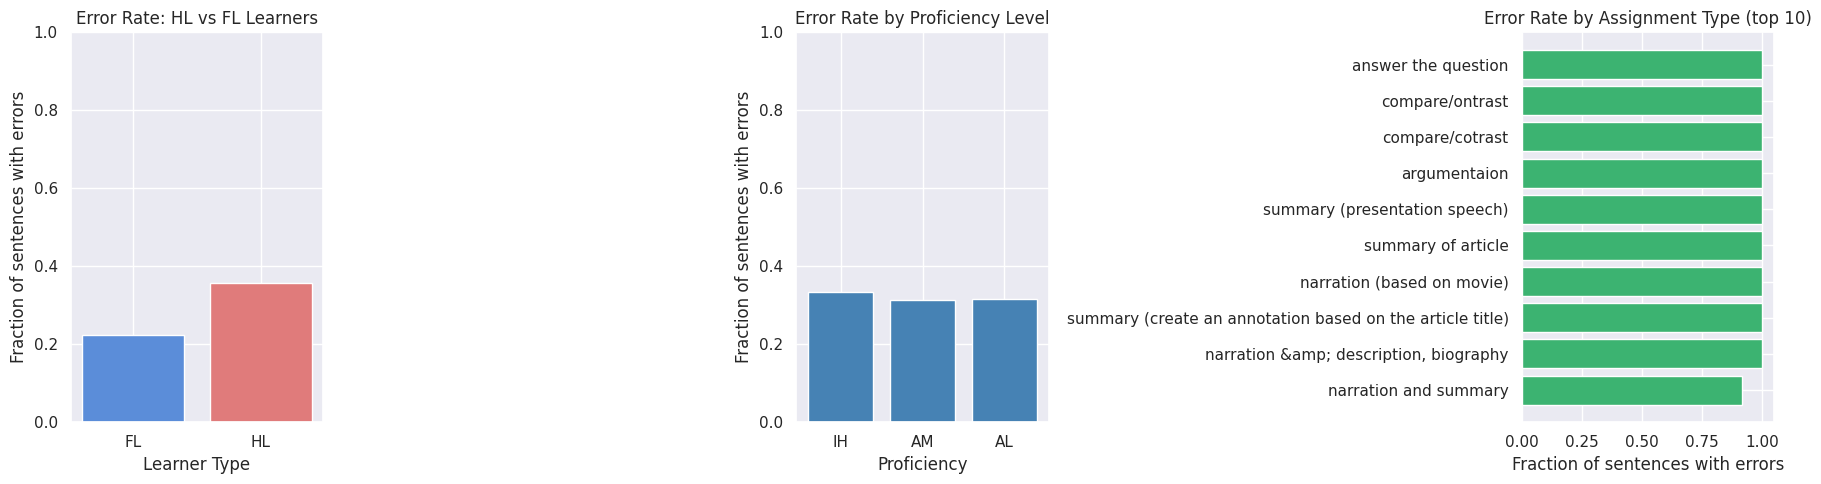

In [45]:
profile = raw.merge(
    doc_meta[['document_id', 'heritage_level', 'proficiency', 'level', 'assignment_type']],
    on='document_id', how='left'
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

hl_err = profile.groupby('heritage_level')['has_error'].mean().dropna()
axes[0].bar(hl_err.index.astype(str), hl_err.values, color=['#5b8dd9', '#e07b7b'])
axes[0].set_title('Error Rate: HL vs FL Learners')
axes[0].set_xlabel('Learner Type')
axes[0].set_ylabel('Fraction of sentences with errors')
axes[0].set_ylim(0, 1)

prof_order = ['IH', 'AM', 'AL']
avail = [p for p in prof_order if p in profile['proficiency'].dropna().unique()]
prof_err = profile.groupby('proficiency')['has_error'].mean().reindex(avail).dropna()
axes[1].bar(prof_err.index.astype(str), prof_err.values, color='steelblue')
axes[1].set_title('Error Rate by Proficiency Level')
axes[1].set_xlabel('Proficiency')
axes[1].set_ylabel('Fraction of sentences with errors')
axes[1].set_ylim(0, 1)

asgn_err = (profile.groupby('assignment_type')['has_error']
             .mean().dropna().sort_values(ascending=False).head(10))
axes[2].barh(list(reversed(asgn_err.index.astype(str))), list(reversed(asgn_err.values)), color='mediumseagreen')
axes[2].set_title('Error Rate by Assignment Type (top 10)')
axes[2].set_xlabel('Fraction of sentences with errors')

plt.tight_layout()
plt.show()

Heritage Language (HL) learners show a different error rate compared to Foreign Language (FL) learners. Higher proficiency correlates with fewer errors across assignment types. The assignment type breakdown reveals that certain genres (e.g., oral transcripts, summaries) have higher error rates.

# 14. Feature correlation matrix

How do sentence length, error density, lexical diversity, and similarity relate to each other?

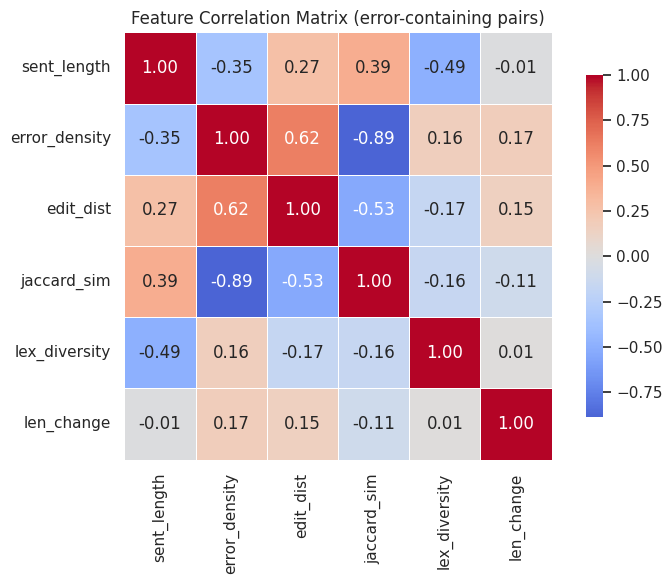

In [46]:
# Build a combined feature frame from the error subset
feature_df = err_df[['sentence_length','error_density','edit_distance','jaccard_sim',
                      'lexical_diversity_text','len_change']].copy()
feature_df.columns = ['sent_length','error_density','edit_dist','jaccard_sim',
                      'lex_diversity','len_change']

corr = feature_df.corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            mask=np.zeros_like(corr))  # show full matrix
plt.title('Feature Correlation Matrix (error-containing pairs)')
plt.tight_layout()
plt.show()


Unsurprisingly, `edit_dist` and `error_density` are strongly positively correlated, and both are negatively correlated with `jaccard_sim`. Sentence length has only weak correlation with error density — longer sentences aren't proportionally more error-prone.

# 15. Trigram analysis on error vs. corrected text

Comparing the most common trigrams reveals which grammatical constructions are most frequently involved in corrections.

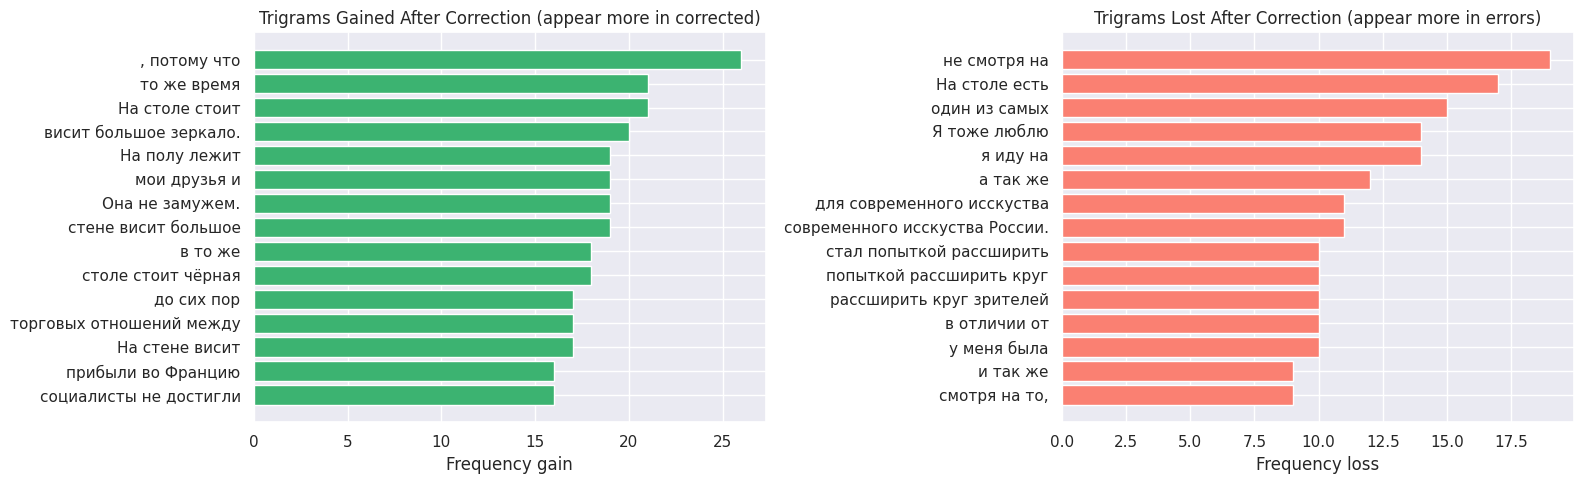

In [47]:
from nltk.util import ngrams as nltk_ngrams

trigram_err  = Counter([g for sent in df['text'].tolist()
                          for g in nltk_ngrams(sent.split(), 3)])
trigram_corr = Counter([g for sent in df['corrected'].tolist()
                          for g in nltk_ngrams(sent.split(), 3)])

# Trigrams that appear much more in corrected than in error text
gained = {g: trigram_corr[g] - trigram_err.get(g, 0) for g in trigram_corr}
lost = {g: trigram_err[g]  - trigram_corr.get(g, 0) for g in trigram_err}

top_gained = sorted(gained.items(), key=lambda x: -x[1])[:15]
top_lost = sorted(lost.items(), key=lambda x: -x[1])[:15]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

labels_g, vals_g = zip(*top_gained)
axes[0].barh([' '.join(g) for g in reversed(labels_g)],
             list(reversed(vals_g)), color='mediumseagreen')
axes[0].set_title('Trigrams Gained After Correction (appear more in corrected)')
axes[0].set_xlabel('Frequency gain')

labels_l, vals_l = zip(*top_lost)
axes[1].barh([' '.join(g) for g in reversed(labels_l)],
             list(reversed(vals_l)), color='salmon')
axes[1].set_title('Trigrams Lost After Correction (appear more in errors)')
axes[1].set_xlabel('Frequency loss')

plt.tight_layout()
plt.show()


Gained trigrams in the corrected text often reflect fixed grammatical constructions and correct preposition use. Lost trigrams represent systematic learner errors — specific phrases that consistently need correction. This can guide rule-based post-processing.

# 16. Summary statistics table

Consolidated view of the key corpus metrics for inclusion in the diploma.

In [48]:
summary = {
    'Total sentence pairs (raw)': len(raw),
    'Pairs with actual errors': int(df['has_error'].sum()),
    'Identical pairs (no error)': int((~df['has_error']).sum()),
    'Error rate (%)': round(100 * df['has_error'].mean(), 1),
    'Unique documents (authors)': raw['document_id'].nunique(),
    'Median sentence length (tokens)': int(df['sentence_length'].median()),
    'Max sentence length (tokens)': int(df['sentence_length'].max()),
    'Median word-level edit distance': round(err_df['edit_distance'].median(), 2),
    'Median error density': round(err_df['error_density'].median(), 3),
    'Median Jaccard similarity': round(err_df['jaccard_sim'].median(), 3),
    'Median character edit distance': round(sample_char['char_edit_dist'].median(), 1),
    'Substitution share of edits (%)': round(100 * total_edits['n_subs'] / total_edits.sum(), 1),
    'Insertion share of edits (%)': round(100 * total_edits['n_ins'] / total_edits.sum(), 1),
    'Deletion share of edits (%)': round(100 * total_edits['n_dels'] / total_edits.sum(), 1),
}

summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=['Value'])
summary_df.to_csv('corpus_summary.csv')
summary_df


,Value
Total sentence pairs (raw),198907.000
Pairs with actual errors,50655.000
Identical pairs (no error),170067.000
Error rate (%),22.900
Unique documents (authors),12399.000
Median sentence length (tokens),11.000
Max sentence length (tokens),1051.000
Median word-level edit distance,1.000
Median error density,0.111
Median Jaccard similarity,0.778


Overall: 198,907 raw sentence pairs from 12,399 learner documents. After splitting and deduplication, 22.9% contain errors. The typical correction changes 1 word (~11% of tokens, ~4 characters). Substitutions dominate overwhelmingly (87%). These numbers set a realistic baseline for what a GEC model needs to handle.